<a target="_blank" href="https://colab.research.google.com/github/wilhelm-lab/koina/blob/main/clients/python/test/notebooks/koinapy.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

# Koina Workshop

This notebook is prepared to be run in Google [Colaboratory](https://colab.research.google.com/).
It contains tasks that are designed to guide new users through the following topics:

1. How to install koina & load packages
2. Basic principle of how to get predictions via koina (explained based on fragment ion intensity prediction)
3. How to visualize experimental and/or predicted fragment ion intensity spectra
4. How to compare fragment ion intensity spectra predictions of different models via koina
    * general principle
    * on an HLA example
5. How to compare RT predictions via koina

# 1: Installation
Before using Koina, the package and dependencies need to be installed. This step is only required once on your notebook, but it may need to be repeated upon reloading Google Colab.

## Task 1.1

What are the requirements for Koina and where do you find this information? (Hint: check out the [README](https://github.com/wilhelm-lab/koina/blob/main/clients/python/README.md) in the github repository).

## Task 1.2

Execute the below code cells, which installs spectrum_utils and Koina.

In [ ]:
!python --version

In [ ]:
# os.system install required to prevent version conflicts on google colab
import os
os.system("pip install --quiet git+https://github.com/bittremieux/spectrum_utils seaborn koinapy")

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 239.0/239.0 kB 14.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 111.9/111.9 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 73.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.9/5.9 MB 96.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 323.4/323.4 kB 17.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 55.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
grpcio-status 1.71.2 requires grpcio>=1.71.2, but you have grpcio 1.67.1 which is incompatible.
grpcio-status 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 6.33.6 which is incompatible.
google-ai-gen

## Task 1.3

For this notebook to work, a few packages need to be imported that provide the functions used in the following. They should already be installed as dependencies of Koins. Should you get an error here, check that installation of the required packages was successful.

Import the below packages and functions by executing the code in the cell.

In [ ]:
# Basic imports
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# To plot masss spectra
import spectrum_utils.plot as sup
import spectrum_utils.spectrum as sus

# To download fasta
import requests
import gzip
import subprocess

# To digest fasta
from pyteomics.fasta import FASTA
from pyteomics.parser import cleave

# Predictions with Koina
from koinapy import Koina
from koinapy import __version__ as version

If this works, you have installed Koina correctly.

## Task 1.4
How can you check that you are using the current stable version?

In [ ]:
version

# 2: Get predictions

Koina provides predictions as a service. You can choose from a growing set of pretrained models.

## Task 2.1

Where do you find information about the available models and how to access them? (Hint: on the [koina website](https://koina.proteomicsdb.org/docs))

## Task 2.2

Define below variables accordingly.

In [ ]:
server = "koina.wilhelmlab.org"   # the server to use for predictions
ssl = True   # whether to use a secure server connection using SSL (Secure Sockets Layer)

## Task 2.3

Run the next cell to instantiate an object storing all the information required for the upcoming prediction.

In [ ]:
prosit2019 = Koina("Prosit_2019_intensity", server_url=server, ssl=ssl)

## Task 2.4



In [ ]:
# Example data
data = pd.DataFrame(
    {
        "peptide_sequences": np.array(
            ["VLHPLEGAVVIIFK", "VLHPLEGAVVLIFK", "SGVSRKPAPG"]
        ),
        "precursor_charges": np.array([2, 2, 2]),
        "collision_energies": np.array([25, 25, 25]),
        "instrument_types": np.array(["LUMOS", "LUMOS", "LUMOS"]),
    }
)

In [5]:
# Checkout input data
data

,peptide_sequences,precursor_charges,collision_energies,instrument_types
0,VLHPLEGAVVIIFK,2,25,LUMOS
1,VLHPLEGAVVLIFK,2,25,LUMOS
2,SGVSRKPAPG,2,25,LUMOS


In [6]:
# Get predictions
pred_prosit2019 = prosit2019.predict(data)

Prosit_2019_intensity::   0%|          | 0/1 [00:00<?, ?it/s]

In [7]:
for key, val in pred_prosit2019.items():
    print(key.ljust(12), val.shape, val[0][:4])

peptide_sequences (89,) 0    VLHPLEGAVVIIFK
0    VLHPLEGAVVIIFK
0    VLHPLEGAVVIIFK
0    VLHPLEGAVVIIFK
Name: peptide_sequences, dtype: object
precursor_charges (89,) 0    2
0    2
0    2
0    2
Name: precursor_charges, dtype: int64
collision_energies (89,) 0    25
0    25
0    25
0    25
Name: collision_energies, dtype: int64
instrument_types (89,) 0    LUMOS
0    LUMOS
0    LUMOS
0    LUMOS
Name: instrument_types, dtype: object
intensities  (89,) 0    0.038753
0    0.105803
0    0.052672
0    1.000000
Name: intensities, dtype: float32
mz           (89,) 0    147.112808
0    294.181213
0    407.265289
0    350.218658
Name: mz, dtype: float32
annotation   (89,) 0    b'y1+1'
0    b'y2+1'
0    b'y3+1'
0    b'b3+1'
Name: annotation, dtype: object


# Visualize spectra using spectrum_utils

<Axes: xlabel='m/z', ylabel='Intensity'>

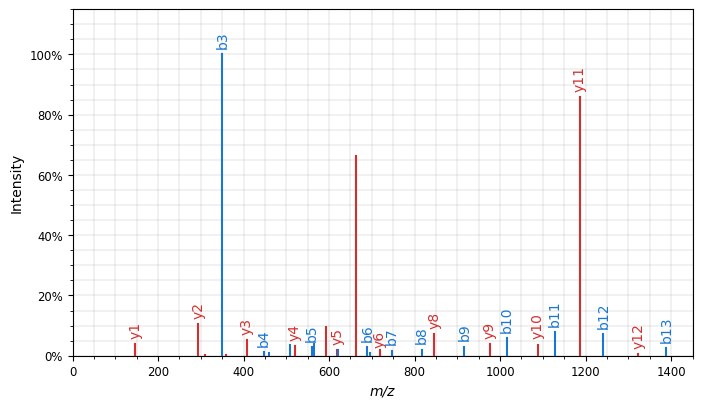

In [8]:
# Initialize a sus.spectrum with our predictions
bot_spectrum = sus.MsmsSpectrum(
    "0", 0, 2, mz=pred_prosit2019["mz"][0], intensity=pred_prosit2019["intensities"][0]
)
# Annotate the spectrum with its ProForma string.
bot_spectrum = bot_spectrum.annotate_proforma(
    "VLHPLEGAVVIIFK", 20, "ppm", ion_types="by", max_ion_charge=2
)

# Plot the spectrum.
fig, ax = plt.subplots(figsize=(8, 4.5))
sup.spectrum(bot_spectrum, ax=ax)

<Axes: xlabel='m/z', ylabel='Intensity'>

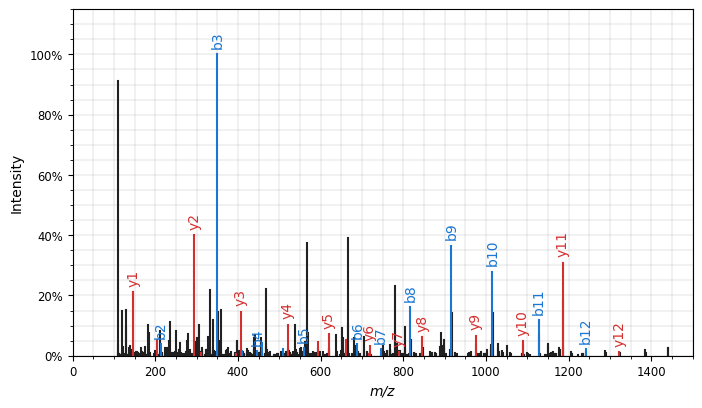

In [9]:
# Initialize a sus.spectrum with an experimental spectrum
top_spectrum = sus.MsmsSpectrum.from_usi(
    "mzspec:PXD000561:Adult_Frontalcortex_bRP_Elite_85_f09:scan:17555:VLHPLEGAVVIIFK/2"
)
# Annotate the spectrum with its ProForma string.
top_spectrum = top_spectrum.annotate_proforma(
    "VLHPLEGAVVIIFK", 20, "ppm", ion_types="by", max_ion_charge=2
)

# Plot the spectrum.
fig, ax = plt.subplots(figsize=(8, 4.5))
sup.spectrum(top_spectrum, ax=ax)

<Axes: xlabel='m/z', ylabel='Intensity'>

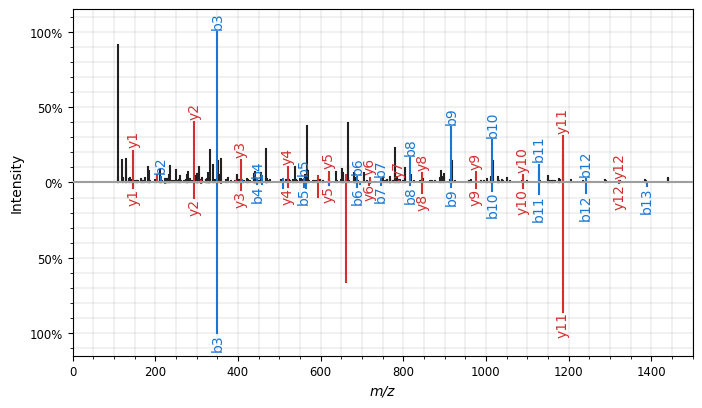

In [10]:
# Create mirror spectra with sup.mirror
fig, ax = plt.subplots(figsize=(8, 4.5))
sup.mirror(top_spectrum, bot_spectrum, ax=ax)

# Compare predictions of different models

In [11]:
prosit2020 = Koina("Prosit_2020_intensity_HCD", server_url=server, ssl=ssl)
ms2pip = Koina("ms2pip_2021_HCD", server_url=server, ssl=ssl)
alphapep = Koina("AlphaPept_ms2_generic", server_url=server, ssl=ssl)

pred_prosit2020 = prosit2020.predict(data)
pred_ms2pip = ms2pip.predict(data)
pred_alphapep = alphapep.predict(data)

Prosit_2020_intensity_HCD::   0%|          | 0/1 [00:00<?, ?it/s]

ms2pip_2021_HCD::   0%|          | 0/1 [00:00<?, ?it/s]

AlphaPept_ms2_generic::   0%|          | 0/1 [00:00<?, ?it/s]

<Axes: title={'center': 'Prosit_202_intensity_HCD'}, xlabel='m/z', ylabel='Intensity'>

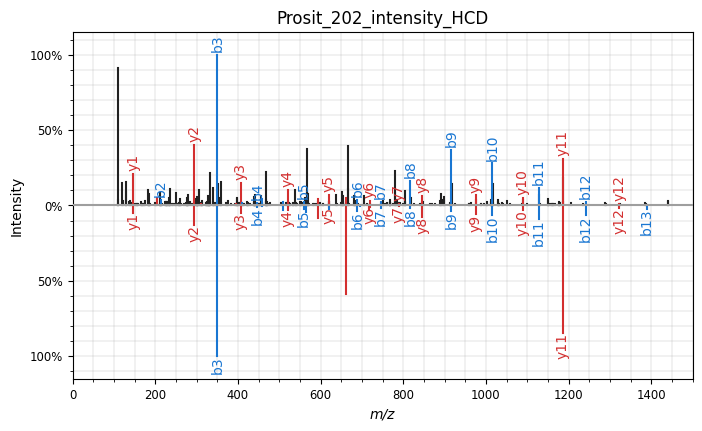

In [12]:
bot_spectrum = sus.MsmsSpectrum(
    "0", 0, 2, mz=pred_prosit2020["mz"][0], intensity=pred_prosit2020["intensities"][0]
)
bot_spectrum = bot_spectrum.annotate_proforma(
    "VLHPLEGAVVIIFK", 20, "ppm", ion_types="by", max_ion_charge=2
)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.set_title("Prosit_202_intensity_HCD")
sup.mirror(top_spectrum, bot_spectrum, ax=ax)

<Axes: title={'center': 'ms2pip_2021_HCD'}, xlabel='m/z', ylabel='Intensity'>

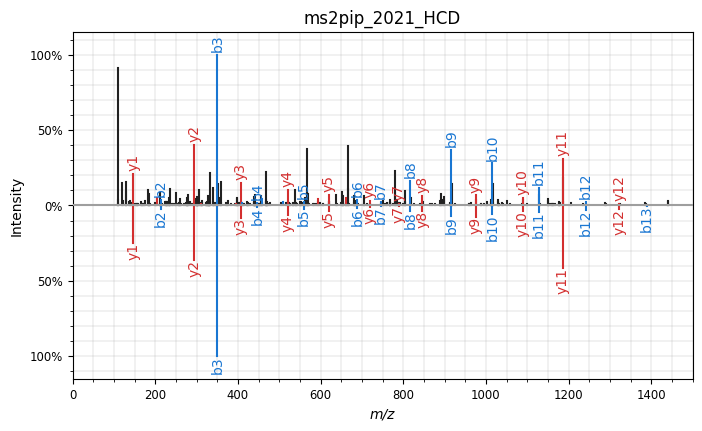

In [13]:
bot_spectrum = sus.MsmsSpectrum(
    "0", 0, 2, mz=pred_ms2pip["mz"][0], intensity=pred_ms2pip["intensities"][0]
)
bot_spectrum = bot_spectrum.annotate_proforma(
    "VLHPLEGAVVIIFK", 20, "ppm", ion_types="by", max_ion_charge=2
)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.set_title("ms2pip_2021_HCD")
sup.mirror(top_spectrum, bot_spectrum, ax=ax)

<Axes: title={'center': 'AlphaPept_ms2_generic'}, xlabel='m/z', ylabel='Intensity'>

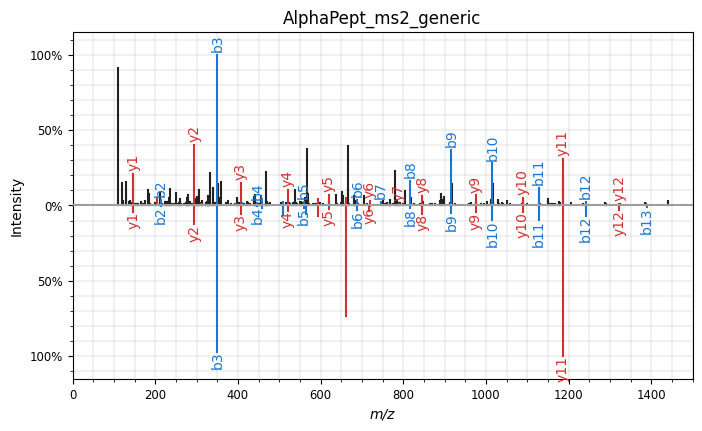

In [14]:
bot_spectrum = sus.MsmsSpectrum(
    "0", 0, 2, mz=pred_alphapep["mz"][0], intensity=pred_alphapep["intensities"][0]
)
bot_spectrum = bot_spectrum.annotate_proforma(
    "VLHPLEGAVVIIFK", 20, "ppm", ion_types="by", max_ion_charge=2
)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.set_title("AlphaPept_ms2_generic")
sup.mirror(top_spectrum, bot_spectrum, ax=ax)

# Validate HLA peptides

<Axes: xlabel='m/z', ylabel='Intensity'>

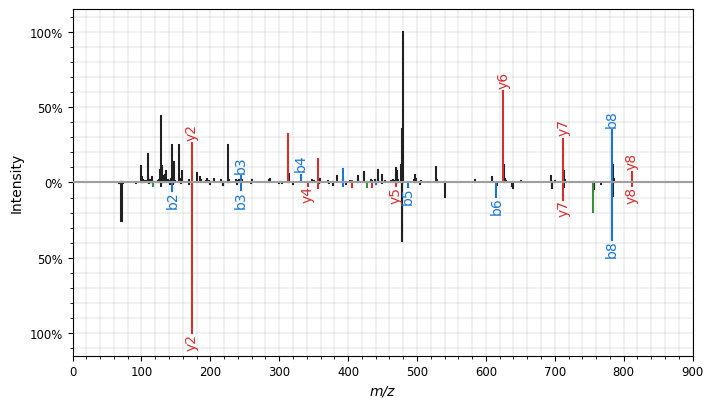

In [ ]:
# Identification originally used to reported a novel HLA peptide (Mylonas et al.4 Figure 2A).
usi = "mzspec:PXD000394:20130504_EXQ3_MiBa_SA_Fib-2:scan:4234"
peptide = "SGVSRKPAPG"
spectrum = sus.MsmsSpectrum.from_usi(usi)

# Process the spectrum.
fragment_tol_mass, fragment_tol_mode = 10, "ppm"
top_spectrum = spectrum.annotate_proforma(
        peptide, fragment_tol_mass, fragment_tol_mode, ion_types="aby",max_ion_charge=2
    )


# Spectrum of a synthetic peptide for the same peptide SGVSRKPAPG/2 revealing a distinctively different fragmentation pattern from example 4a.
usi = "mzspec:PXD010793:20170817_QEh1_LC1_HuPa_SplicingPep_10pmol_G2_R01:scan:8296"
peptide = "SGVSRKPAPG"
spectrum = sus.MsmsSpectrum.from_usi(usi)

# Process the spectrum.
fragment_tol_mass, fragment_tol_mode = 10, "ppm"
bot_spectrum = spectrum.annotate_proforma(
        peptide, fragment_tol_mass, fragment_tol_mode, ion_types="aby",max_ion_charge=2
    )

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.set_title("Experimental vs. synthetic spectrum for peptide SGVSRKPAPG")
sup.mirror(top_spectrum, bot_spectrum, ax=ax)

## Use Prosit_2019_intensity



<Axes: title={'center': 'Synthetic vs Prosit_2019_intensity'}, xlabel='m/z', ylabel='Intensity'>

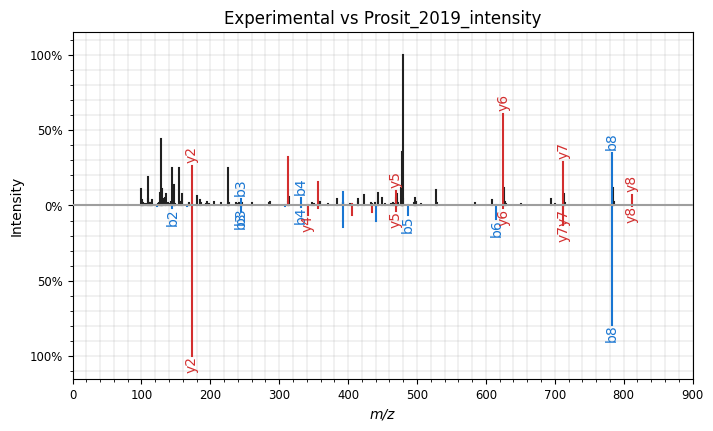

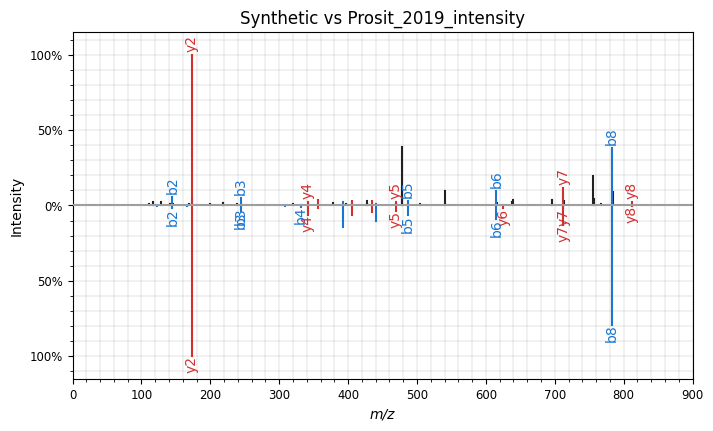

In [39]:
# Identification originally used to reported a novel HLA peptide (Mylonas et al.4 Figure 2A).
usi = "mzspec:PXD000394:20130504_EXQ3_MiBa_SA_Fib-2:scan:4234"
peptide = "SGVSRKPAPG"
spectrum = sus.MsmsSpectrum.from_usi(usi)

# Process the spectrum.
fragment_tol_mass, fragment_tol_mode = 20, "ppm"
top_spectrum = spectrum.annotate_proforma(
        peptide, fragment_tol_mass, fragment_tol_mode, ion_types="by",max_ion_charge=2
    )

bot_spectrum = sus.MsmsSpectrum(
    "0", 0, 2, mz=pred_prosit2019["mz"][2], intensity=pred_prosit2019["intensities"][2]
)
bot_spectrum = bot_spectrum.annotate_proforma(
    "SGVSRKPAPG", 10, "ppm", ion_types="aby", max_ion_charge=2
)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.set_title("Experimental vs Prosit_2019_intensity")
sup.mirror(top_spectrum, bot_spectrum, ax=ax)

# Spectrum of a synthetic peptide for the same peptide SGVSRKPAPG/2 revealing a distinctively different fragmentation pattern from example 4a.
usi = "mzspec:PXD010793:20170817_QEh1_LC1_HuPa_SplicingPep_10pmol_G2_R01:scan:8296"
peptide = "SGVSRKPAPG"
spectrum = sus.MsmsSpectrum.from_usi(usi)

# Process the spectrum.
fragment_tol_mass, fragment_tol_mode = 20, "ppm"
top_spectrum = spectrum.annotate_proforma(
        peptide, fragment_tol_mass, fragment_tol_mode, ion_types="by",max_ion_charge=2
    )



fig, ax = plt.subplots(figsize=(8, 4.5))
ax.set_title("Synthetic vs Prosit_2019_intensity")
sup.mirror(top_spectrum, bot_spectrum, ax=ax)

## Use ms2pip_2021

<Axes: title={'center': 'Synthetic vs ms2pip'}, xlabel='m/z', ylabel='Intensity'>

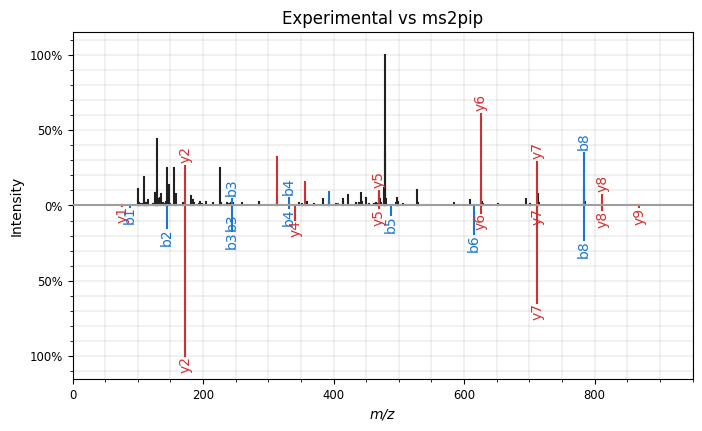

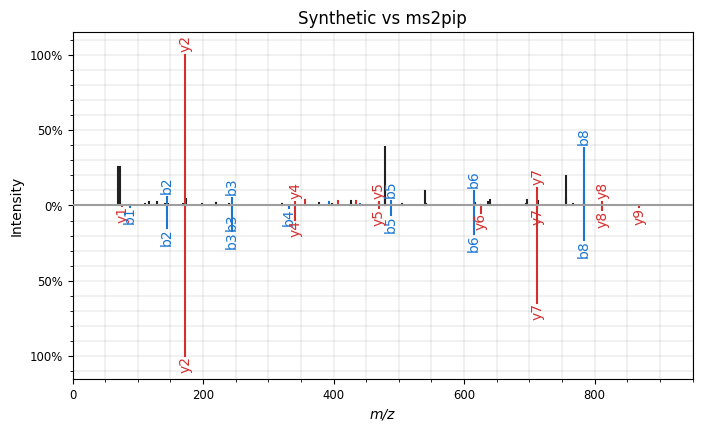

In [43]:
# Identification originally used to reported a novel HLA peptide (Mylonas et al.4 Figure 2A).
usi = "mzspec:PXD000394:20130504_EXQ3_MiBa_SA_Fib-2:scan:4234"
peptide = "SGVSRKPAPG"
spectrum = sus.MsmsSpectrum.from_usi(usi)

# Process the spectrum.
fragment_tol_mass, fragment_tol_mode = 20, "ppm"
top_spectrum = spectrum.annotate_proforma(
        peptide, fragment_tol_mass, fragment_tol_mode, ion_types="by",max_ion_charge=2
)


bot_spectrum = sus.MsmsSpectrum(
    "0", 0, 2, mz=pred_ms2pip["mz"][2], intensity=pred_ms2pip["intensities"][2]
)
bot_spectrum = bot_spectrum.annotate_proforma(
    "SGVSRKPAPG", 20, "ppm", ion_types="by", max_ion_charge=2
)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.set_title("Experimental vs ms2pip")
sup.mirror(top_spectrum, bot_spectrum, ax=ax)

# Spectrum of a synthetic peptide for the same peptide SGVSRKPAPG/2 revealing a distinctively different fragmentation pattern from example 4a.
usi = "mzspec:PXD010793:20170817_QEh1_LC1_HuPa_SplicingPep_10pmol_G2_R01:scan:8296"
peptide = "SGVSRKPAPG"
spectrum = sus.MsmsSpectrum.from_usi(usi)

# Process the spectrum.
fragment_tol_mass, fragment_tol_mode = 20, "ppm"
top_spectrum = spectrum.annotate_proforma(
        peptide, fragment_tol_mass, fragment_tol_mode, ion_types="by",max_ion_charge=2
    )


bot_spectrum = sus.MsmsSpectrum(
    "0", 0, 2, mz=pred_ms2pip["mz"][2], intensity=pred_ms2pip["intensities"][2]
)
bot_spectrum = bot_spectrum.annotate_proforma(
    "SGVSRKPAPG", 20, "ppm", ion_types="by", max_ion_charge=2
)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.set_title("Synthetic vs ms2pip")
sup.mirror(top_spectrum, bot_spectrum, ax=ax)

## Use AlpaPept




<Axes: title={'center': 'Synthetic vs AlphaPept'}, xlabel='m/z', ylabel='Intensity'>

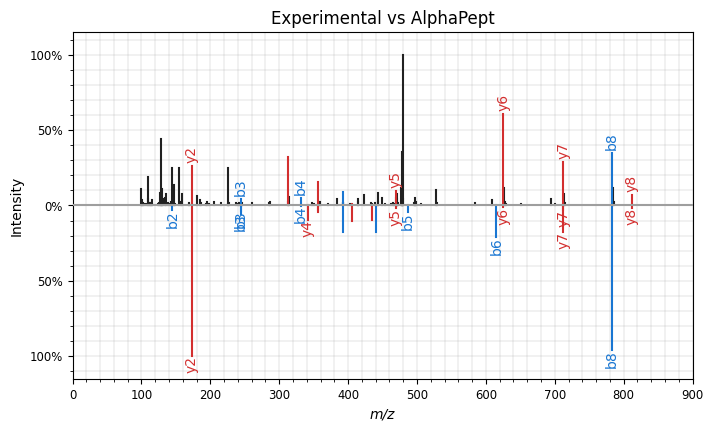

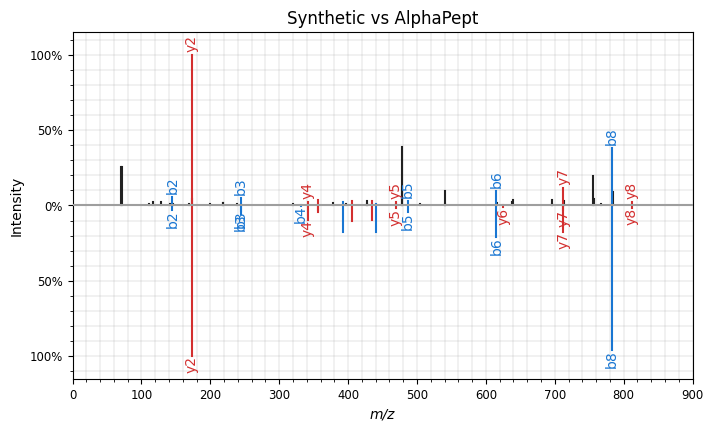

In [45]:
# Identification originally used to reported a novel HLA peptide (Mylonas et al.4 Figure 2A).
usi = "mzspec:PXD000394:20130504_EXQ3_MiBa_SA_Fib-2:scan:4234"
peptide = "SGVSRKPAPG"
spectrum = sus.MsmsSpectrum.from_usi(usi)

# Process the spectrum.
fragment_tol_mass, fragment_tol_mode = 20, "ppm"
top_spectrum = spectrum.annotate_proforma(
        peptide, fragment_tol_mass, fragment_tol_mode, ion_types="by",max_ion_charge=2
)

bot_spectrum = sus.MsmsSpectrum(
    "0", 0, 2, mz=pred_alphapep["mz"][2], intensity=pred_alphapep["intensities"][2]
)
bot_spectrum = bot_spectrum.annotate_proforma(
    "SGVSRKPAPG", 20, "ppm", ion_types="by", max_ion_charge=2
)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.set_title("Experimental vs AlphaPept")
sup.mirror(top_spectrum, bot_spectrum, ax=ax)

# Spectrum of a synthetic peptide for the same peptide SGVSRKPAPG/2 revealing a distinctively different fragmentation pattern from example 4a.
usi = "mzspec:PXD010793:20170817_QEh1_LC1_HuPa_SplicingPep_10pmol_G2_R01:scan:8296"
peptide = "SGVSRKPAPG"
spectrum = sus.MsmsSpectrum.from_usi(usi)

# Process the spectrum.
fragment_tol_mass, fragment_tol_mode = 20, "ppm"
top_spectrum = spectrum.annotate_proforma(
        peptide, fragment_tol_mass, fragment_tol_mode, ion_types="by",max_ion_charge=2
    )

bot_spectrum = sus.MsmsSpectrum(
    "0", 0, 2, mz=pred_alphapep["mz"][2], intensity=pred_alphapep["intensities"][2]
)
bot_spectrum = bot_spectrum.annotate_proforma(
    "SGVSRKPAPG", 20, "ppm", ion_types="by", max_ion_charge=2
)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.set_title("Synthetic vs AlphaPept")
sup.mirror(top_spectrum, bot_spectrum, ax=ax)

# Retention time comparison


In [16]:
url = "https://ftp.uniprot.org/pub/databases/uniprot/current_release/knowledgebase/reference_proteomes/Eukaryota/UP000005640/UP000005640_9606.fasta.gz"
myfile = requests.get(url)

with open("UP000005640_9606.fasta.gz", "wb") as f_in:
    f_in.write(myfile.content)

_ = subprocess.run(["gunzip", "UP000005640_9606.fasta.gz"])

In [17]:
# Create peptides dataframe

# Digest fasta
peptides = set()
for prot in FASTA("UP000005640_9606.fasta"):
    peptides.update(cleave(prot.sequence, "trypsin", min_length=7, max_length=30))

#
data = pd.DataFrame({"peptide_sequences": np.array(list(peptides))})


data = data[~data["peptide_sequences"].str.contains("X|U")]
# data = data.loc[data["peptide_sequences"].str.len().sort_values().index]
data["peptide_sequences"] = data["peptide_sequences"].str.replace("C", "C[UNIMOD:4]")

In [18]:
data

,peptide_sequences
0,NGTVATALAFITSFLTLSWYTTWQNGK
1,VDEDSAEDTQSNDGK
2,DILEPQNER
3,DTVLLLHGLSQK
4,SALQSHQPVARPVSVGLSR
...,...
486944,KPAGPSVSELIVQAASSSK
486945,APEHPAPPATAVR
486946,NHSVLQR
486947,ESGYNMIHFTPLQTLGLSR


In [19]:
prosit2019_irt = Koina("Prosit_2019_irt", server_url=server, ssl=ssl)
deeplc = Koina("Deeplc_hela_hf", server_url=server, ssl=ssl)

In [20]:
data["prosit_irt"] = prosit2019_irt.predict(data)["irt"]
data["deeplc_irt"] = deeplc.predict(data)["irt"]

Prosit_2019_irt::   0%|          | 0/487 [00:00<?, ?it/s]

Deeplc_hela_hf::   0%|          | 0/487 [00:00<?, ?it/s]

<Axes: xlabel='prosit_irt', ylabel='Count'>

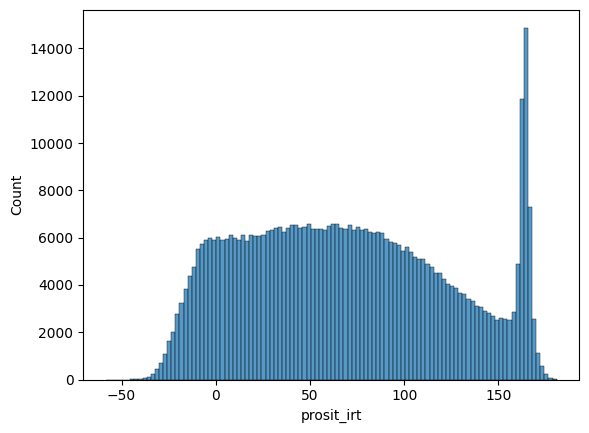

In [21]:
sns.histplot(data, x="prosit_irt")

<Axes: xlabel='deeplc_irt', ylabel='Count'>

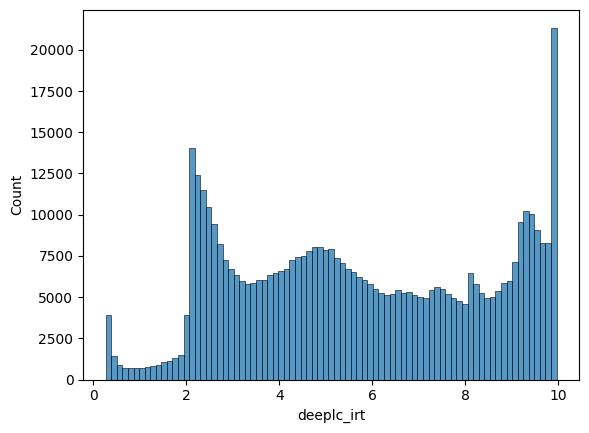

In [22]:
sns.histplot(data, x="deeplc_irt")

<Axes: xlabel='prosit_irt', ylabel='deeplc_irt'>

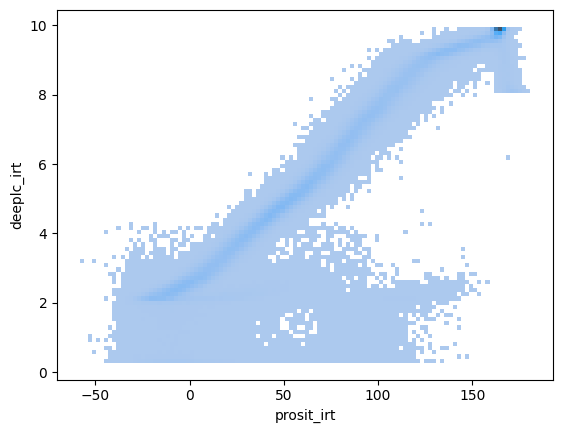

In [23]:
sns.histplot(data, x="prosit_irt", y="deeplc_irt")

In [24]:
data[["prosit_irt", "deeplc_irt"]].corr(method="pearson")

,prosit_irt,deeplc_irt
prosit_irt,1.000000,0.956261
deeplc_irt,0.956261,1.000000
